# Variational Autoencoder (VAE) Handwritten Digit Generation Demo

- This demo shows how to train and use a Variational Autoencoder (VAE) to generate synthetic handwritten digits.
- The model learns to encode and reconstruct digits from the MNIST dataset, a collection of handwritten digit images (0-9).

#### Key Concepts
- *Variational Autoencoder (VAE)*: A generative deep learning model that learns a probabilistic latent space to generate new images.
- *Encoder-Decoder Architecture*: The encoder compresses input images into a latent space, and the decoder reconstructs images from the latent space.
- *MNIST Dataset*: A collection of 28x28 grayscale images of handwritten digits, commonly used for training image-processing models.
- *Latent Space Representation*: Instead of directly memorizing images, the VAE learns a structured representation that allows meaningful generation of new samples.

#### Steps in the Demo
1. *Load and Preprocess the MNIST Dataset*:
   - Normalize images to [0,1] range and reshape them for model input.
2. *Define the VAE Architecture*:
   - Build an encoder-decoder network using convolutional layers.
3. *Train the VAE Model*:
   - Optimize using a reconstruction loss (Binary Cross-Entropy) and KL divergence to enforce a smooth latent space.
4. *Generate Handwritten Digits**:
   - Sample from the learned latent space to create new synthetic digits.
5. *Visualize Generated Digits*:
   - Display generated handwritten digit images to evaluate model performance.

#### Applications of This Demo
- *Data Augmentation*: Generate additional digit images for training machine learning models.
- *Anomaly Detection*: Use latent representations to detect outliers in handwritten digits. Outliers in the input will show a significantly higer loss when reconstructed


#### **Setting Up the Anaconda Environment**
To run this demo, follow these steps to set up an Anaconda environment with the required dependencies.

1. **Create and activate the environment**:
```bash
   conda create --name vae_demo python=3.9 -y
   conda activate vae_demo
```

2. **Install required libraries**:
```bash
   conda install -c conda-forge numpy=1.24.4 matplotlib jupyter -y
   conda install pytorch torchvision torchaudio cpuonly -c pytorch -y  # CPU version
```
   
   If using a GPU, install the CUDA version instead:
```bash
   conda install pytorch torchvision torchaudio pytorch-cuda=11.8 -c pytorch -c nvidia -y
```

3. **Add the environment as a Jupyter Kernel**:
```bash
   pip install ipykernel
   python -m ipykernel install --user --name=vae_demo --display-name "VAE DEMO"
```

4. **Verify installation**:
```bash
   python -c "import torch; print(torch.cuda.is_available())"  # Should return True if GPU is available
```

5. **Run the demo**:
```bash
   jupyter lab
```
- Open a new notebook and select **Kernel → Change Kernel → Python (vae_demo)**.


In [1]:
import sys, platform
print(sys.executable)
print(platform.architecture())

/Users/chrisminnick/Library/CloudStorage/GoogleDrive-chris@watzthis.com/My Drive/WatzThis Projects/Cloud Contraptions/Generative AI/GenAI-Labs/.venv/bin/python
('64bit', 'Mach-O')


In [4]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

print(torch.__version__)

2.11.0


## Step 1: Load and Preprocess the MNIST Dataset

- The MNIST dataset consists of 28x28 grayscale images of handwritten digits (0-9).
- Each image is converted into a PyTorch tensor and normalized to values between 0 and 1.
- `torchvision.datasets.MNIST` downloads the dataset if it is not already available locally.
- The `DataLoader` batches the dataset into groups of 128 images for efficient processing.
- Shuffling the dataset ensures that batches contain diverse samples, improving model generalization.

In [5]:
transform = transforms.ToTensor()
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 332kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.91MB/s]


## Step 2: Define the Variational Autoencoder (VAE) Model

- The VAE consists of an **encoder** and a **decoder**.
- The **encoder** compresses the input image into a latent space representation (smaller numerical form).
- The **latent space** consists of two components: **mean (mu)** and **log variance (log_var)**, which define a probability distribution.
- The  *reparameterization trick* is used to sample a point from this learned distribution, ensuring the model remains differentiable.
- The **decoder** reconstructs the image from the latent space representation.
- The model learns meaningful representations that allow generating new images by sampling from the latent space.


In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 40)  # 20 for mean, 20 for log variance
        )
        self.decoder = nn.Sequential(
            nn.Linear(20, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = h[:, :20], h[:, 20:]
        z = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

# Initialize the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

def vae_loss(recon_x, x, mu, log_var):
    bce_loss = nn.functional.binary_cross_entropy(recon_x, (x + 1) / 2, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return bce_loss + kl_loss


## Step 3: Train the VAE Model
- The model is trained for multiple epochs to learn how to encode and decode digit images.
- Each batch of images is flattened and moved to the appropriate device (CPU/GPU).
- The VAE generates reconstructed images and latent space parameters (mu and log_var).
- The *VAE loss function* consists of two parts:
1. *Reconstruction Loss*: Measures how well the reconstructed image matches the original.
2. *KL Divergence Loss*: Regularizes the latent space to ensure smooth sampling.
- The optimizer updates the model's weights based on computed loss.raining runs for 10 epochs, with loss values printed at each epoch to track progress.

In [7]:
num_epochs = 10  # Adjust based on training time constraints
for epoch in range(num_epochs):
    for images, _ in trainloader:
        images = images.view(images.size(0), -1).to(device)
        optimizer.zero_grad()
        recon_images, mu, log_var = vae(images.to(device))
        loss = vae_loss(recon_images, images, mu, log_var)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 49936.9648
Epoch 2, Loss: 49800.3477
Epoch 3, Loss: 49812.7266
Epoch 4, Loss: 49500.9141
Epoch 5, Loss: 49593.1641
Epoch 6, Loss: 49592.7930
Epoch 7, Loss: 49245.4453
Epoch 8, Loss: 49310.9883
Epoch 9, Loss: 49460.1992
Epoch 10, Loss: 49374.0820


## Step 4: Generate New Handwritten Digits
- After training, the model is set to evaluation mode using `vae.eval()`.
- A random sample `z` is drawn from a standard normal distribution in the latent space.
- The trained *decoder* takes `z` as input and generates new digit images.
- The generated images are reshaped to 28x28 pixels for visualization.

In [8]:
vae.eval()
z = torch.randn(16, 20).to(device)  # Sample from the learned latent space
with torch.no_grad():
    generated_images = vae.decoder(z).view(-1, 1, 28, 28)


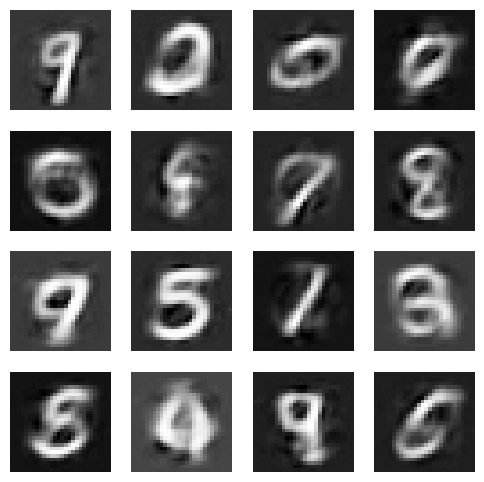

In [9]:
# Step 5: Visualize the Generated Digits
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.show()
